# OpenCourses.AI Colab version

This notebook belongs to **Fundamentos de Transformers** and was published as a public Colab-ready artifact.

Colab is an external free execution option with variable resources. Run the setup cell before executing the rest of the notebook.


In [ ]:
# OpenCourses.AI Colab setup
import importlib, json, os, pathlib, subprocess, sys, tempfile
REPO_URL = "https://github.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb.git"
BRANCH = "main"
VERSION = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
EXPECTED_SOURCE_HASH = "56a5adfc10ebbfbc3a0ec4d850a4d82a48587607fc02a374e3201e8bc79bc7d5"
REQUIRED_FILES = ["assets/audio/notebooks/01_el_problema_de_modelar_secuencias_intro.mp3","assets/audio/notebooks/02_tokens_vocabulario_y_batches_intro.mp3","assets/audio/notebooks/03_embeddings_y_geometria_de_tokens_intro.mp3","assets/audio/notebooks/04_posicion_y_orden_en_secuencias_intro.mp3","assets/audio/notebooks/05_tensores_del_transformer_intro.mp3","assets/audio/notebooks/06_atencion_como_mezcla_ponderada_intro.mp3","assets/audio/notebooks/07_queries_keys_y_values_intro.mp3","assets/audio/notebooks/08_self_attention_matricial_intro.mp3","assets/audio/notebooks/09_atencion_causal_intro.mp3","assets/audio/notebooks/10_multi_head_attention_intro.mp3","assets/audio/notebooks/11_residuales_layernorm_y_mlp_intro.mp3","assets/audio/notebooks/12_bloque_transformer_decoder_intro.mp3","assets/audio/notebooks/13_mini_gpt_desde_cero_intro.mp3","assets/audio/notebooks/14_entrenamiento_autoregresivo_intro.mp3","assets/audio/notebooks/15_generacion_interpretacion_y_limites_intro.mp3","assets/audio/notebooks/16_proyecto_final_intro.mp3","assets/audio/presentacion_curso.mp3","assets/figures/00_presentacion_del_curso.png","assets/figures/01_el_problema_de_modelar_secuencias.png","assets/figures/02_tokens_vocabulario_y_batches.png","assets/figures/03_embeddings_y_geometria_de_tokens.png","assets/figures/04_posicion_y_orden_en_secuencias.png","assets/figures/05_tensores_del_transformer.png","assets/figures/06_atencion_como_mezcla_ponderada.png","assets/figures/07_queries_keys_y_values.png","assets/figures/08_self_attention_matricial.png","assets/figures/09_atencion_causal.png","assets/figures/10_multi_head_attention.png","assets/figures/11_residuales_layernorm_y_mlp.png","assets/figures/12_bloque_transformer_decoder.png","assets/figures/13_mini_gpt_desde_cero.png","assets/figures/14_entrenamiento_autoregresivo.png","assets/figures/15_generacion_interpretacion_y_limites.png","assets/figures/16_proyecto_final.png","assets/readings/unit-10-nota-tecnica.pdf","assets/readings/unit-11-nota-tecnica.pdf","assets/readings/unit-12-nota-tecnica.pdf","assets/readings/unit-13-nota-tecnica.pdf","assets/readings/unit-14-nota-tecnica.pdf","assets/readings/unit-15-nota-tecnica.pdf","assets/readings/unit-16-nota-tecnica.pdf","assets/readings/unit-2-nota-tecnica.pdf","assets/readings/unit-3-nota-tecnica.pdf","assets/readings/unit-4-nota-tecnica.pdf","assets/readings/unit-5-nota-tecnica.pdf","assets/readings/unit-6-nota-tecnica.pdf","assets/readings/unit-7-nota-tecnica.pdf","assets/readings/unit-8-nota-tecnica.pdf","assets/readings/unit-9-nota-tecnica.pdf","notebooks/unit-1.ipynb","notebooks/unit-10.ipynb","notebooks/unit-11.ipynb","notebooks/unit-12.ipynb","notebooks/unit-13.ipynb","notebooks/unit-14.ipynb","notebooks/unit-15.ipynb","notebooks/unit-16.ipynb","notebooks/unit-17.ipynb","notebooks/unit-2.ipynb","notebooks/unit-3.ipynb","notebooks/unit-4.ipynb","notebooks/unit-5.ipynb","notebooks/unit-6.ipynb","notebooks/unit-7.ipynb","notebooks/unit-8.ipynb","notebooks/unit-9.ipynb","opencourses-colab.json","requirements.txt","src/fundamentos_transformers/__init__.py","src/fundamentos_transformers/arquitectura_experimentos.py","src/fundamentos_transformers/atencion.py","src/fundamentos_transformers/atencion_experimentos.py","src/fundamentos_transformers/componentes_interactivos.py","src/fundamentos_transformers/datos.py","src/fundamentos_transformers/embeddings.py","src/fundamentos_transformers/entrenamiento.py","src/fundamentos_transformers/entrenamiento_experimentos.py","src/fundamentos_transformers/generacion.py","src/fundamentos_transformers/generacion_experimentos.py","src/fundamentos_transformers/minigpt_experimentos.py","src/fundamentos_transformers/modelo.py","src/fundamentos_transformers/posicion.py","src/fundamentos_transformers/proyecto_final_experimentos.py","src/fundamentos_transformers/tensores.py","src/fundamentos_transformers/tokenizacion.py","src/fundamentos_transformers/visualizacion.py"]
BASE = pathlib.Path("/content/opencourses/opencourse-fundamentos-de-transformers-d9d23ccb")
BASE.mkdir(parents=True, exist_ok=True)
TARGET = BASE / VERSION
def _snapshot_issue(folder):
    if not (folder / 'notebooks').is_dir():
        return 'the notebooks folder is missing'
    missing = [name for name in REQUIRED_FILES if not (folder / name).is_file()]
    if missing:
        return 'required files are missing: ' + ', '.join(missing[:5])
    if EXPECTED_SOURCE_HASH:
        try:
            manifest = json.loads((folder / 'opencourses-colab.json').read_text(encoding='utf8'))
        except (OSError, ValueError) as error:
            return f'the publication manifest cannot be read: {error}'
        if manifest.get('source_hash') != EXPECTED_SOURCE_HASH:
            return 'the publication version has changed; reopen the latest notebook from OpenCourses.AI'
    return None
if _snapshot_issue(TARGET) is not None:
    recoveries = sorted(BASE.glob(VERSION + '-recovery-*'), key=lambda folder: folder.stat().st_mtime, reverse=True)
    existing = next((folder for folder in recoveries if _snapshot_issue(folder) is None), None)
    if existing is not None:
        TARGET = existing
    elif TARGET.exists():
        print('The course folder is incomplete. Preserving it and downloading a fresh copy.')
        TARGET = pathlib.Path(tempfile.mkdtemp(prefix=VERSION + '-recovery-', dir=BASE))
if _snapshot_issue(TARGET) is not None:
    print('Downloading the course resources...')
    try:
        subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(TARGET)], check=True)
    except Exception as error:
        raise RuntimeError(f'Course download failed. Files in {TARGET} were preserved. Run setup again to retry in a fresh folder.') from error
    issue = _snapshot_issue(TARGET)
    if issue is not None:
        raise RuntimeError(f'Course setup stopped: {issue}. Files in {TARGET} were preserved; no course code was started.')
else:
    print('Using the verified folder for this course version; your local changes are preserved.')
os.environ['COURSE_ROOT'] = str(TARGET)
os.environ['ASSETS_DIR'] = str(TARGET / 'assets')
src_dir = TARGET / 'src'
if src_dir.is_dir():
    if str(src_dir) in sys.path:
        sys.path.remove(str(src_dir))
    sys.path.insert(0, str(src_dir))
importlib.invalidate_caches()
notebooks_dir = TARGET / 'notebooks'
if notebooks_dir.exists():
    os.chdir(notebooks_dir)
requirements = TARGET / 'requirements.txt'
if requirements.exists() and requirements.read_text(encoding='utf8').strip():
    print('Checking the course Python dependencies...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', str(requirements)], check=True)
try:
    from google.colab import output as colab_output
except ImportError:
    pass
else:
    try:
        colab_output.enable_custom_widget_manager()
    except Exception as error:
        print(f'Widget support could not be enabled: {error}')
print(f'COURSE_ROOT={TARGET}')
print('Setup complete. Run the remaining notebook cells from top to bottom.')


<div style="border-bottom: 2px solid #1f2a44; padding-bottom: 14px; margin-bottom: 22px;">
  <div style="display: flex; align-items: center; justify-content: space-between; gap: 24px;">
    <div style="text-align: center; flex: 1; min-width: 260px;">
      <div style="font-size: 14px; letter-spacing: 0.04em; text-transform: uppercase; color: #5b6472;">Fundamentos de Transformers</div>
      <div style="font-size: 15px; font-weight: 700; color: #667085; margin-top: 6px;">Notebook 08</div>
      <div style="font-size: 26px; font-weight: 700; color: #1f2a44; margin-top: 2px;">Autoatención matricial (self-attention)</div>
      <div style="font-size: 14px; color: #5b6472; margin-top: 8px;">Curso abierto</div>
    </div>
  </div>
</div>

<div style="display: flex; justify-content: space-between; gap: 16px; color: #3f4754; font-size: 14px; margin-bottom: 20px; flex-wrap: wrap;">
    <div><strong>Curso:</strong> Fundamentos de Transformers</div>
  <div><strong>Periodo:</strong> 2026-I</div>
</div>


## Presentación del notebook

<audio controls style="width: 100%; margin: 8px 0 18px 0;">
  <source src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/audio/notebooks/08_self_attention_matricial_intro.mp3" type="audio/mpeg">
  Su navegador no puede reproducir el audio embebido.
</audio>


## Pregunta directriz

> ¿Cómo calcula autoatención todas las rutas de información de una secuencia en una sola operación matricial?

En el notebook anterior estudiamos una fila de atención: una consulta $q_t$ se comparaba con todas las llaves y luego mezclaba valores. Ahora damos el paso matricial: todas las posiciones de la secuencia hacen esa operación simultáneamente.

Esta forma matricial no es únicamente una conveniencia de PyTorch: también es la razón por la que autoatención puede procesar muchas posiciones en paralelo y producir una salida contextual para cada una. La clave es leer cada fila de la matriz como una distribución independiente.

## Objetivos

Al finalizar este notebook, el estudiante debería poder:

1. Derivar la forma matricial de la autoatención a partir de la lectura por filas del notebook anterior.
2. Interpretar $S \in \mathbb{R}^{T \times T}$ como matriz de puntajes y $A \in \mathbb{R}^{T \times T}$ como matriz de pesos por fila.
3. Verificar que cada fila de $A$ suma uno y que cada salida $Y_t$ es una mezcla de valores.
4. Implementar y auditar la operación $Y=AV$ con tensores pequeños en PyTorch.
5. Reconocer que una matriz de atención muestra rutas de información bajo una configuración, no una explicación semántica definitiva.


## Marco conceptual

Autoatención significa que la misma secuencia produce consultas, llaves y valores. Cada posición consulta a la secuencia completa, incluida ella misma, y construye una nueva representación contextual. El cálculo por filas sigue siendo válido, pero se organiza como una multiplicación de matrices.

La idea central es pasar de una pregunta individual:

$$
\text{para una posición } t, \text{ ¿qué posiciones } j \text{ aportan contenido?}
$$

a una tabla completa de preguntas:

$$
\text{para cada posición } t, \text{ ¿qué pesos asigna sobre todas las posiciones } j?
$$

Esa tabla es la matriz de atención $A$. Las filas corresponden a posiciones que consultan; las columnas corresponden a posiciones consultadas. Antes de $A$ aparece $S$, la matriz de puntajes sin normalizar. Después, $A$ multiplica a $V$ para producir una salida contextual $Y$ con una fila por posición.

El límite conceptual se mantiene: $A$ indica pesos de mezcla bajo las proyecciones actuales. No basta mirar una celda alta para concluir que el modelo entiende una relación lingüística robusta.

## Idea visual: matriz de autoatención

<div style="text-align: center; margin: 12px 0 18px 0;">
  <img src="https://raw.githubusercontent.com/opencourses-ai-colab/opencourse-fundamentos-de-transformers-d9d23ccb/main/assets/figures/08_self_attention_matricial.png" alt="Autoatención matricial" style="width: min(980px, 98%); height: auto; border: 1px solid #d0d7de; border-radius: 6px;">
</div>

La figura resume el paso desde filas individuales hacia una matriz completa. Cada fila de $S$ contiene puntajes; cada fila de $A$ contiene pesos después de softmax. La salida se obtiene al multiplicar esos pesos por $V$.

La lectura importante es que todas las posiciones producen pesos y salidas de manera simultánea, pero cada fila conserva la misma interpretación local que estudiamos en el notebook anterior.

## Formulación matemática

Sea $X \in \mathbb{R}^{T \times C}$ una secuencia representada por $T$ posiciones y $C$ canales. A partir de $X$ se calculan:

$$
Q = XW_Q,
\qquad
K = XW_K,
\qquad
V = XW_V,
$$

con $Q,K,V \in \mathbb{R}^{T \times D}$.

Esta ecuación se lee así: todas las posiciones se proyectan simultáneamente en consultas, llaves y valores.

La matriz de puntajes se calcula como:

$$
S = \frac{QK^\top}{\sqrt{D}},
\qquad
S \in \mathbb{R}^{T \times T}.
$$

Esta ecuación se lee así: cada entrada $S_{tj}$ compara la consulta de la posición $t$ con la llave de la posición $j$. $S$ contiene puntajes sin normalizar, no pesos todavía.

El factor $1/\sqrt{D}$ reduce la escala de los productos punto. Sin esa escala, al crecer $D$ los puntajes tienden a crecer en magnitud, softmax puede volverse demasiado concentrado y los gradientes pueden ser menos estables.

Luego se aplica softmax por filas:

$$
A_{tj} = \frac{\exp(S_{tj})}{\sum_{r=1}^{T}\exp(S_{tr})}.
$$

Esta ecuación se lee así: para cada consulta fija $t$, la fila $A_{t,:}$ se convierte en una distribución independiente sobre posiciones $j$.

Finalmente:

$$
Y = AV,
\qquad
Y \in \mathbb{R}^{T \times D}.
$$

Esta ecuación se lee así: cada fila $Y_t$ se reconstruye como $A_{t,:} @ V$, una mezcla ponderada de los valores.

## Traducción tensorial

En un lote real, aparece el eje $B$:

$$
Q,K,V \in \mathbb{R}^{B \times T \times D},
\qquad
S,A \in \mathbb{R}^{B \times T \times T},
\qquad
Y \in \mathbb{R}^{B \times T \times D}.
$$

La transposición de $K$ se hace sobre los dos últimos ejes. Computacionalmente, PyTorch evalúa una multiplicación por lote:

$$
QK^\top: (B,T,D) \times (B,D,T) \rightarrow (B,T,T).
$$

Esta ecuación se lee así: el eje $D$ se usa para calcular compatibilidades y desaparece del resultado; quedan dos ejes de posición, consulta $t$ y llave $j$.

Después:

$$
AV: (B,T,T) \times (B,T,D) \rightarrow (B,T,D).
$$

Esta ecuación se lee así: el eje de posiciones consultadas se usa para mezclar valores, y la salida recupera una fila de dimensión $D$ por cada posición que consulta.

## Preparación del entorno


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import fundamentos_transformers.atencion_experimentos as atencion_experimentos
import fundamentos_transformers.componentes_interactivos as componentes_interactivos
import fundamentos_transformers.visualizacion as visualizacion

atencion_experimentos = importlib.reload(atencion_experimentos)
componentes_interactivos = importlib.reload(componentes_interactivos)
visualizacion = importlib.reload(visualizacion)

crear_explorador_self_attention_matricial = componentes_interactivos.crear_explorador_self_attention_matricial
configurar_matplotlib = visualizacion.configurar_matplotlib
mostrar_tablas_en_columnas = visualizacion.mostrar_tablas_en_columnas

configurar_matplotlib()
torch.manual_seed(7)
np.random.seed(7)


## Experimento mínimo

Construiremos un batch con una secuencia de $T=5$ posiciones y dimensión $D=6$. Antes de ejecutar, conviene anticipar las formas:

- $Q,K,V$ deben conservar los ejes $(B,T,D)$.
- $S$ y $A$ deben tener forma $(B,T,T)$ porque comparan cada consulta contra cada llave.
- $Y$ debe volver a forma $(B,T,D)$ porque cada fila mezcla valores.

La inspección se concentrará en la fila $t=2$ para comprobar que la lectura por filas coincide con el cálculo matricial completo.

etapa,forma antes,forma despues,eje que cambia,significado
"proyectar Q,K,V","(1, 5, 6)","(1, 5, 6)",C -> D,crea roles separados
QK^T,"(1, 5, 6) x (1, 6, 5)","(1, 5, 5)",D desaparece,scores crudos entre t y j
escala / sqrt(D),"(1, 5, 5)","(1, 5, 5)",no cambia forma,controla magnitud de scores
softmax por fila,"(1, 5, 5)","(1, 5, 5)",normaliza eje j,convierte scores en pesos
AV,"(1, 5, 5) x (1, 5, 6)","(1, 5, 6)",T consultado -> D,mezcla valores
j,"S[2,j] score","A[2,j] peso",V[j] canal 1,aporte c1
0,0.428,0.262,0.428,0.112000
1,0.208,0.210,-0.077,-0.016000
2,0.046,0.179,0.586,0.105000
3,0.242,0.217,-0.326,-0.071000


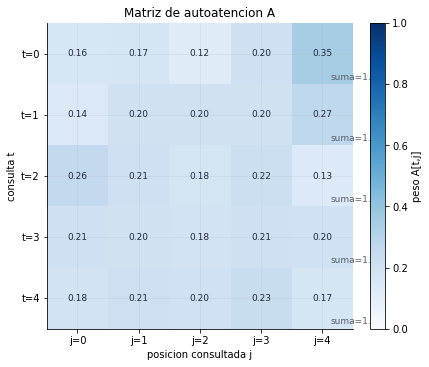

In [2]:
resultado_self_attention = atencion_experimentos.preparar_self_attention_matricial(seed=2)

mostrar_tablas_en_columnas(
    [
        ("Etapas matriciales", resultado_self_attention.etapas),
        ("Fila t=2", resultado_self_attention.fila),
        ("Verificaciones", resultado_self_attention.verificaciones),
        ("Lectura de S, A y Y", resultado_self_attention.lectura_fila),
    ],
    min_width="380px",
)


La auditoría confirma la diferencia entre puntajes y pesos. $S$ tiene forma $(B,T,T)$, pero sus valores todavía no son una distribución. Después de aplicar softmax por filas obtenemos $A$, donde cada fila suma uno.

La fila $t=2$ muestra la continuidad con el notebook anterior: $S[2,:]$ contiene comparaciones, $A[2,:]$ contiene pesos y $A[2,:] @ V$ reconstruye exactamente la salida $Y[2]$.

## Visualización de la matriz de atención

La matriz de calor permite leer todas las filas de $A$ al mismo tiempo. El eje vertical indica la consulta $t$; el eje horizontal indica la posición consultada $j$. Cada fila debe interpretarse como una distribución independiente y debe sumar uno.

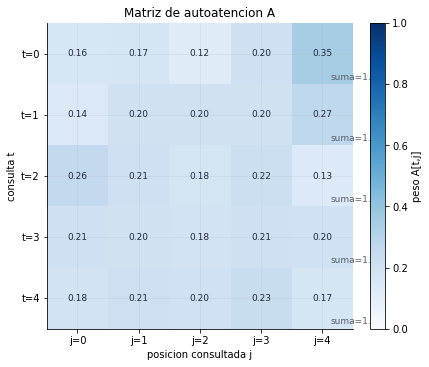

In [3]:
display(resultado_self_attention.figura)
plt.close(resultado_self_attention.figura)


Un patrón diagonal alto indicaría que varias posiciones se asignan mucho peso a sí mismas. Eso puede ocurrir, pero no debe interpretarse automáticamente como comprensión. En este experimento las proyecciones son aleatorias; la matriz sirve para leer el mecanismo, no para evaluar lenguaje.

La lectura operacional es más importante: cada fila de $A$ define desde dónde toma información una posición, y $AV$ aplica todas esas mezclas en paralelo.

## Explorador interactivo

El explorador permite seleccionar una fila $t$ de la matriz de atención. Para esa fila muestra puntajes, pesos, aportes al primer canal de salida y verificación de que $Y_t=A_{t,:}V$.

Úsalo como una lupa: la matriz completa calcula todas las filas a la vez, pero cada fila conserva la lectura local de una consulta contra todas las llaves.

In [4]:
crear_explorador_self_attention_matricial()


## Verificación de aprendizaje

Usa el explorador y responde con evidencia:

1. Selecciona dos filas distintas de $A$. ¿Cambian las posiciones con mayor peso?
2. Verifica que cada fila suma uno. ¿Por qué esa propiedad depende de aplicar softmax por filas?
3. Explica por qué $S$ y $A$ tienen forma $T \times T$, pero $Y$ tiene forma $T \times D$.
4. Reconstruye una salida: toma una fila $A[t,:]$ y explica cómo produce $Y_t$ al multiplicarse por $V$.
5. Describe qué significaría una diagonal dominante y por qué no basta para hacer una conclusión semántica.

La respuesta debe citar una fila de la tabla o una celda específica de la matriz de atención.

## Análisis crítico

Lo observado puede leerse en tres niveles:

1. **Qué ocurrió:** todas las posiciones calcularon puntajes contra todas las posiciones, esos puntajes se normalizaron por fila y luego mezclaron valores.
2. **Por qué ocurrió:** la forma matricial $QK^\top$ construye todas las comparaciones $t,j$ simultáneamente, y $AV$ aplica todas las mezclas en paralelo.
3. **Qué límite tiene la conclusión:** una matriz de atención no prueba significado lingüístico por sí sola. Su interpretación depende de datos, entrenamiento, arquitectura, capa, cabeza y contexto.

Este notebook enseña la estructura computacional que luego recibirá una restricción causal en modelos autoregresivos. La tabla de etapas también sirve para depurar errores reales: si una forma no coincide, conviene identificar si el problema ocurrió en scores, softmax por fila o mezcla con $V$.

## Síntesis

La cadena operacional del notebook es:

$$
Q,K,V \rightarrow S=QK^\top/\sqrt{D} \rightarrow A=\operatorname{softmax}(S) \rightarrow Y=AV.
$$

Esta cadena se lee así: todas las consultas se comparan con todas las llaves, cada fila de puntajes se normaliza como distribución y cada salida mezcla valores.

<div style="border-left: 4px solid #1f2a44; padding: 10px 14px; background: #f6f8fa; margin-top: 10px;">
La idea central es que autoatención convierte una secuencia en una tabla completa de rutas de información: cada fila de A define una mezcla y todas las filas producen Y en paralelo.
</div>

## Preguntas de discusión

1. ¿Por qué cada fila de $A$ suma uno, pero las columnas no necesariamente?
2. ¿Qué información se pierde si solo miramos el valor máximo de cada fila?
3. ¿Por qué $A$ no contiene contenido, aunque determine rutas de información?
4. ¿Qué cambia entre estudiar una fila aislada y estudiar la matriz completa?
5. ¿Por qué los modelos autoregresivos necesitan restringir esta matriz en el siguiente notebook?


## Continuidad

El siguiente notebook introduce la máscara causal. En autoatención no restringida, una posición puede mirar posiciones futuras. Para predicción autoregresiva, eso sería fuga de información. La máscara causal modifica la matriz de atención para que cada posición solo use información permitida.
